In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")

In [6]:
def find_repo_root(start_path: Path) -> Path:
    for path in [start_path, *start_path.parents]:
        if (path / "data" / "processed").exists():
            return path
    for child in start_path.iterdir():
        if child.is_dir() and (child / "data" / "processed").exists():
            return child
    raise FileNotFoundError("Could not locate the repository root containing data/processed")

BASE_DIR = find_repo_root(Path().resolve())
DATA_PATH = BASE_DIR / "data" / "processed"
REPORT_PATH = BASE_DIR / "reports"
REPORT_PATH.mkdir(exist_ok=True)
print(f"BASE_DIR={BASE_DIR}")
print(f"DATA_PATH={DATA_PATH}")

BASE_DIR=D:\Workplace\Bluestocks Internship\MutualFundAnalytics
DATA_PATH=D:\Workplace\Bluestocks Internship\MutualFundAnalytics\data\processed


In [7]:
nav = pd.read_csv(DATA_PATH / "clean_nav.csv")
nav["date"] = pd.to_datetime(nav["date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [10]:
returns = nav.dropna(
    subset=["daily_return"]
)
returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [11]:
risk_summary = []

for code, group in returns.groupby("amfi_code"):
    var95 = np.percentile(
        group["daily_return"],
        5
    )
    cvar95 = group.loc[
        group["daily_return"] <= var95,
        "daily_return"
    ].mean()
    risk_summary.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })
risk_df = pd.DataFrame(risk_summary)
risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [12]:
risk_df = risk_df.sort_values(
    "VaR_95"
)
risk_df

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [13]:
risk_df.to_csv(
    REPORT_PATH / "var_cvar_report.csv",
    index=False
)
print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


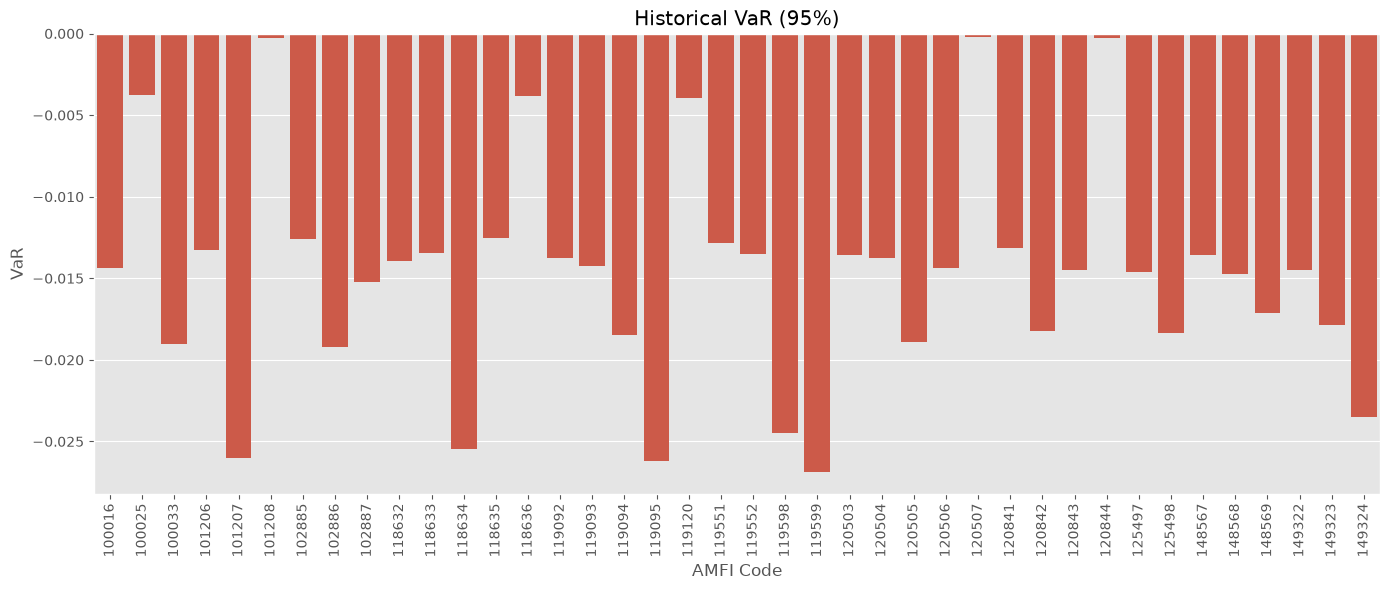

In [14]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=risk_df,
    x="amfi_code",
    y="VaR_95"
)

plt.title("Historical VaR (95%)")
plt.xlabel("AMFI Code")
plt.ylabel("VaR")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Observation

- VaR represents the expected worst daily loss at the 95% confidence level.
- More negative VaR values indicate higher downside risk.
- CVaR measures the average loss when returns fall below the VaR threshold, giving insight into tail risk.

In [15]:
# Annual risk-free rate
risk_free_rate = 0.06

# Daily risk-free rate
daily_rf = risk_free_rate / 252

In [16]:
rolling_data = []
for code, group in returns.groupby("amfi_code"):
    group = group.sort_values("date").copy()
    rolling_mean = group["daily_return"].rolling(90).mean()
    rolling_std = group["daily_return"].rolling(90).std()
    sharpe = np.sqrt(252) * (
        (rolling_mean - daily_rf) / rolling_std
    )

    group["rolling_sharpe"] = sharpe
    rolling_data.append(group)
rolling_df = pd.concat(rolling_data)
rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN


In [17]:
rolling_df.to_csv(
    REPORT_PATH / "rolling_sharpe.csv",
    index=False
)
print("rolling_sharpe.csv saved successfully!")

rolling_sharpe.csv saved successfully!


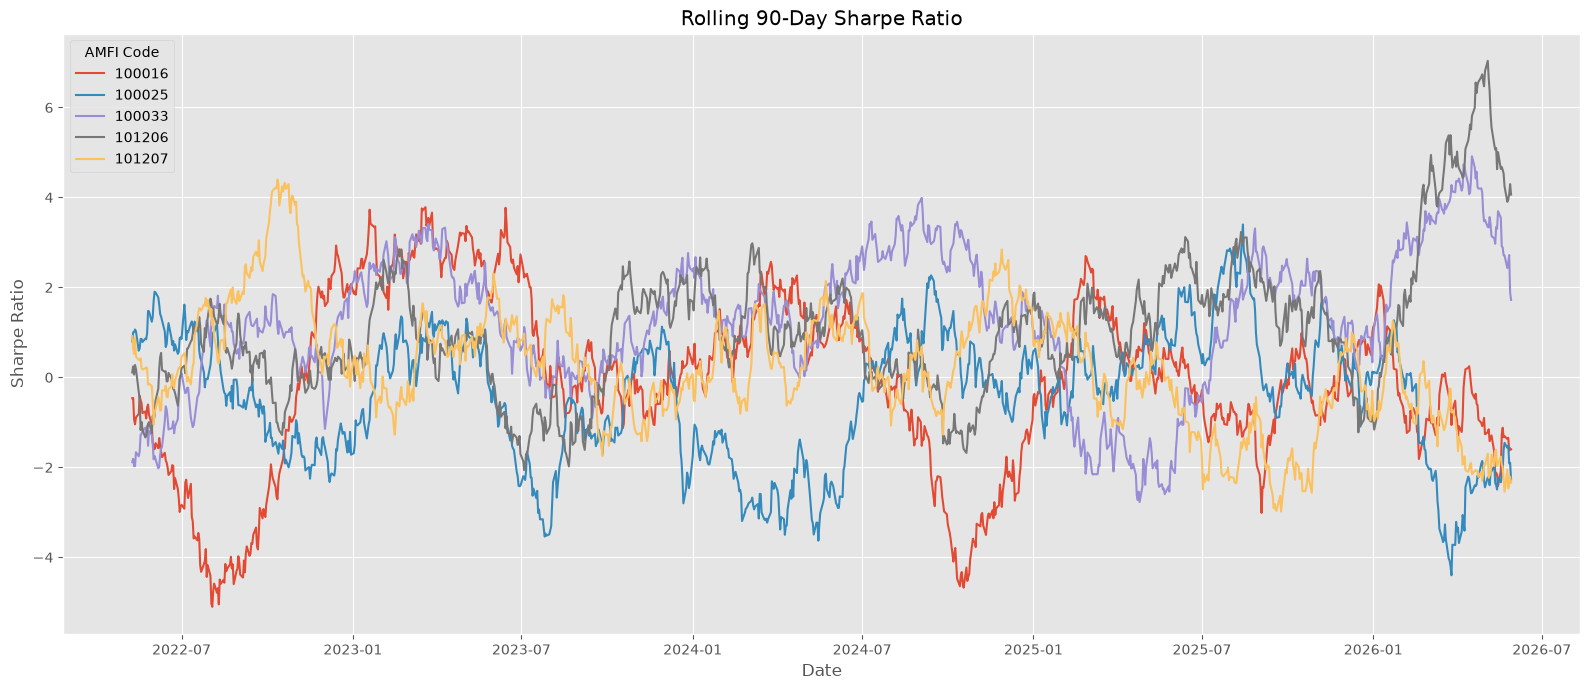

In [18]:
top5 = rolling_df["amfi_code"].unique()[:5]
plt.figure(figsize=(16,7))
for code in top5:
    temp = rolling_df[
        rolling_df["amfi_code"] == code
    ]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.tight_layout()
plt.show()

In [19]:
plt.figure(figsize=(16,7))
for code in top5:
    temp = rolling_df[
        rolling_df["amfi_code"] == code
    ]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )
plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(
    REPORT_PATH / "rolling_sharpe_chart.png",
    dpi=300
)
plt.close()
print("rolling_sharpe_chart.png saved successfully!")

rolling_sharpe_chart.png saved successfully!


## Observation

- Rolling Sharpe Ratio measures how the risk-adjusted performance changes over time.
- Higher values indicate better returns per unit of risk.
- Significant fluctuations may indicate periods of increased market volatility or changing fund performance.

In [20]:
transactions = pd.read_csv(
    DATA_PATH / "clean_investor_transactions.csv"
)
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,Upi,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [21]:
transactions["transaction_month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)
transactions["cohort_month"] = (
    transactions.groupby("investor_id")["transaction_month"]
    .transform("min")
)
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_month,cohort_month
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,Upi,Verified,2024-01,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01,2024-01
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01,2024-01


In [22]:
transactions["cohort_index"] = (
    (transactions["transaction_month"].dt.year -
     transactions["cohort_month"].dt.year) * 12
    +
    (transactions["transaction_month"].dt.month -
     transactions["cohort_month"].dt.month)
)

In [23]:
cohort = (
    transactions
    .groupby(["cohort_month", "cohort_index"])
    ["investor_id"]
    .nunique()
    .reset_index()
)
cohort.head()

,cohort_month,cohort_index,investor_id
0,2024-01,0,1577
1,2024-01,1,540
2,2024-01,2,567
3,2024-01,3,541
4,2024-01,4,550


In [24]:
cohort_pivot = cohort.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="investor_id"
)
cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
cohort_month,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0,NaN
2024-03,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0,NaN,NaN
2024-04,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0,NaN,NaN,NaN
2024-05,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0,NaN,NaN,NaN,NaN
2024-06,236.0,61.0,73.0,50.0,79.0,60.0,59.0,74.0,59.0,70.0,68.0,54.0,NaN,NaN,NaN,NaN,NaN
2024-07,175.0,45.0,40.0,41.0,43.0,36.0,40.0,36.0,41.0,38.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,135.0,24.0,32.0,30.0,31.0,29.0,34.0,34.0,23.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,17.0,19.0,22.0,21.0,20.0,13.0,19.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(
    cohort_size,
    axis=0
)
retention = retention * 100
retention

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
cohort_month,,,,,,,,,,,,,,,,,
2024-01,100.0,34.242232,35.954344,34.305644,34.876347,35.827521,34.622701,34.749524,33.164236,35.890932,34.495878,34.939759,36.271401,32.847178,34.051997,34.559290,37.159163
2024-02,100.0,35.959596,37.070707,35.555556,35.555556,35.353535,37.878788,34.545455,31.818182,35.151515,35.151515,35.757576,31.919192,35.050505,32.222222,32.727273,NaN
2024-03,100.0,31.240658,35.127055,37.070254,31.838565,31.240658,31.240658,31.838565,30.642750,32.137519,34.678625,27.503737,33.781764,34.529148,31.240658,NaN,NaN
2024-04,100.0,27.210884,31.065760,31.519274,29.024943,31.519274,34.013605,29.024943,29.931973,31.746032,29.251701,31.065760,30.612245,31.746032,NaN,NaN,NaN
2024-05,100.0,26.190476,35.714286,29.931973,25.850340,26.530612,27.210884,34.693878,30.272109,25.510204,30.272109,27.210884,28.911565,NaN,NaN,NaN,NaN
2024-06,100.0,25.847458,30.932203,21.186441,33.474576,25.423729,25.000000,31.355932,25.000000,29.661017,28.813559,22.881356,NaN,NaN,NaN,NaN,NaN
2024-07,100.0,25.714286,22.857143,23.428571,24.571429,20.571429,22.857143,20.571429,23.428571,21.714286,21.142857,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.0,17.777778,23.703704,22.222222,22.962963,21.481481,25.185185,25.185185,17.037037,27.407407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,17.000000,19.000000,22.000000,21.000000,20.000000,13.000000,19.000000,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


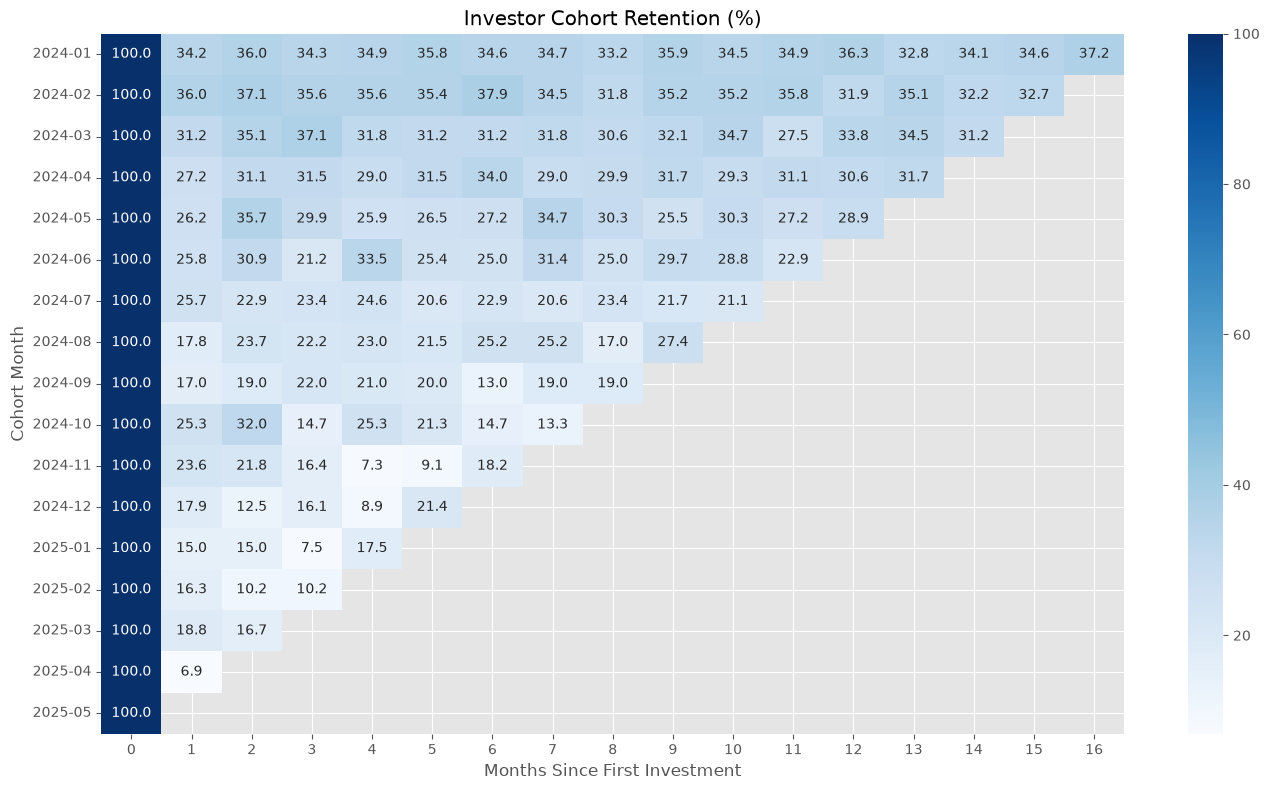

In [26]:
plt.figure(figsize=(14,8))
sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Investor Cohort Retention (%)")
plt.xlabel("Months Since First Investment")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

In [27]:
retention.to_csv(REPORT_PATH / "cohort_analysis.csv")
print("cohort_analysis.csv saved successfully!")

cohort_analysis.csv saved successfully!


## Observation

- Investors are grouped based on the month of their first transaction.
- The heatmap shows the percentage of investors who remained active in subsequent months.
- Darker shades indicate higher investor retention.
- This analysis helps identify long-term investor engagement trends.

In [34]:
sip = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

sip["transaction_date"] = pd.to_datetime(
    sip["transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_month,cohort_month,cohort_index
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,Upi,Verified,2024-01,2024-01,0
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01,0
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01,0
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024-01,2024-01,0
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024-01,2024-01,0


In [35]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [36]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)
sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_month,cohort_month,cohort_index,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,Upi,Verified,2024-11,2024-11,0,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025-01,2024-11,2,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024-03,2024-03,0,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024-09,2024-03,6,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025-05,2024-03,14,238.0


In [37]:
sip_summary = (
    sip.groupby("investor_id")
       .agg(
           sip_transactions=("investor_id", "count"),
           average_gap_days=("gap_days", "mean")
       )
       .reset_index()
)
sip_summary.head()

,investor_id,sip_transactions,average_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [38]:
sip_summary = sip_summary[
    sip_summary["sip_transactions"] >= 6
]
sip_summary.head()

,investor_id,sip_transactions,average_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [39]:
sip_summary["status"] = sip_summary[
    "average_gap_days"
].apply(
    lambda x: "At Risk" if x > 35 else "Active"
)

sip_summary.head()

,investor_id,sip_transactions,average_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [40]:
sip_summary.to_csv(
    REPORT_PATH / "sip_continuity.csv",
    index=False
)
print("sip_continuity.csv saved successfully!")

sip_continuity.csv saved successfully!


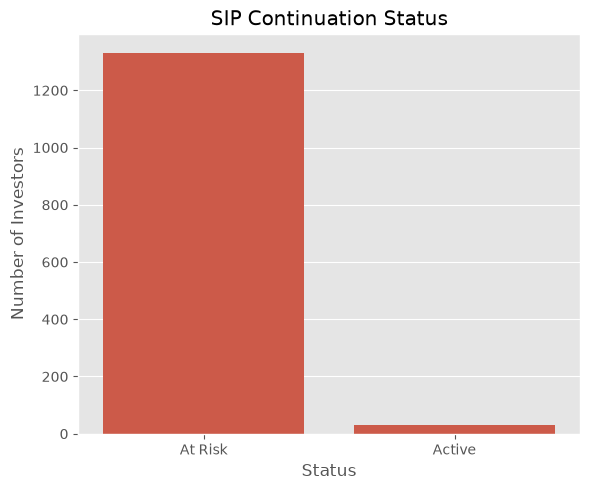

In [41]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=sip_summary,
    x="status"
)

plt.title("SIP Continuation Status")
plt.xlabel("Status")
plt.ylabel("Number of Investors")
plt.tight_layout()
plt.show()

## Observation

- Investors with six or more SIP transactions were analysed.
- The average gap between consecutive SIPs was calculated.
- Investors with an average gap greater than 35 days were flagged as **At Risk**.

In [42]:
portfolio = pd.read_csv(DATA_PATH / "clean_portfolio_holdings.csv")
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,100016,BAJFINANCE,Bajaj Finance Ltd,Nbfc,7.01,214.89,592.41,2025-12-31
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31
2,100016,DRREDDY,Dr. Reddy'S Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31
3,100016,HINDUNILVR,Hindustan Unilever Ltd,Fmcg,11.68,1590.03,2555.06,2025-12-31
4,100016,ICICIBANK,Icici Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31


In [43]:
hhi = (
    portfolio.groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)
hhi["weight_fraction"] = hhi["weight_pct"] / 100
hhi["square"] = hhi["weight_fraction"] ** 2

sector_hhi = (
    hhi.groupby("amfi_code")["square"]
    .sum()
    .reset_index()
)
sector_hhi.rename(
    columns={"square": "HHI"},
    inplace=True
)
sector_hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [44]:
sector_hhi.to_csv(
    REPORT_PATH / "sector_hhi.csv",
    index=False
)
print("sector_hhi.csv saved successfully!")

sector_hhi.csv saved successfully!


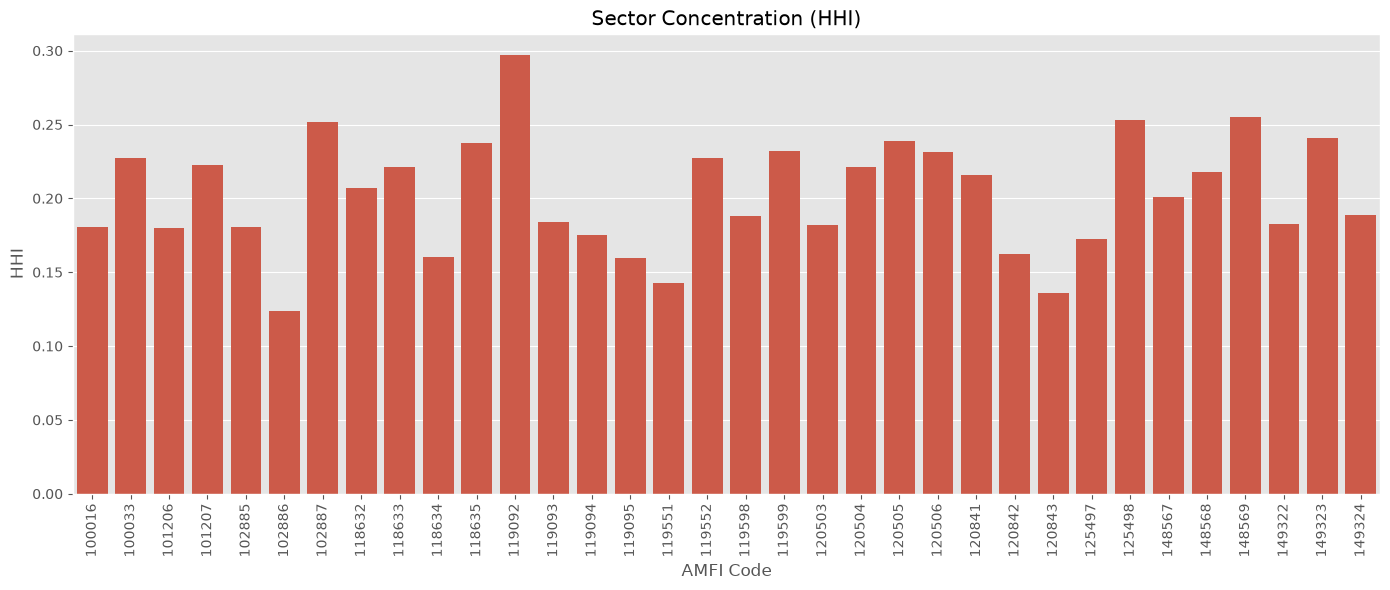

In [45]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=sector_hhi,
    x="amfi_code",
    y="HHI"
)

plt.title("Sector Concentration (HHI)")
plt.xlabel("AMFI Code")
plt.ylabel("HHI")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Observation

- Higher HHI indicates a portfolio concentrated in fewer sectors.
- Lower HHI indicates better sector diversification.
- HHI helps assess concentration risk across mutual fund portfolios.

# Advanced Analytics Summary

## Key Findings

1. Historical VaR and CVaR identified downside risk for each mutual fund using daily NAV returns.

2. Rolling 90-Day Sharpe Ratio showed how risk-adjusted performance changed over time.

3. Investor Cohort Analysis grouped investors by their first transaction month and evaluated retention patterns.

4. SIP Continuation Analysis identified investors with six or more SIP transactions and flagged those with an average transaction gap greater than 35 days as "At Risk."

5. The Fund Recommendation Model recommends the top three mutual funds based on the selected risk appetite using Sharpe Ratio rankings.

6. Sector Concentration Analysis used the Herfindahl-Hirschman Index (HHI) to measure portfolio diversification across sectors.

## Conclusion

The advanced analytics module provides insights into mutual fund risk, investor behaviour, portfolio diversification, and fund recommendations. These analyses support informed investment decisions and form a strong analytical foundation for the dashboard and reporting components of the project.